## **Mục tiêu: Xây dựng mô hình để phân loại ảnh trong bộ dữ liệu CIFAR-10 (gồm 10 loại: máy bay, ô tô, chim, mèo, hươu, chó, ếch, ngựa, tàu thủy, xe tải)**

# **Step1: Cài đặt và Import thư viện**

* Torch & Torchvision: Để xây dựng mô hình.
* TensorBoard: Để theo dõi quá trình train (vẽ biểu đồ).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.tensorboard import SummaryWriter # Dùng cho bài tập 3

# Kiểm tra xem có GPU không (nếu có thì dùng cho nhanh)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# **Step2: Chuẩn bị dữ liệu**

* Bộ dữ liệu CIFAR-10 (gồm 10 loại ảnh)
* ResNet chuẩn thường nhận ảnh 224x224, ta resize ảnh CIFAR (32x32) lên để kết quả tốt hơn

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # phóng to ảnh gốc 32x32 lên 224x224 
    transforms.ToTensor(), # chuyển ảnh sang tensor số học để máy tính hiểu
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # chuẩn hóa màu sắc
])

# Tải dữ liệu CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# Batch size: 32 để train nhanh hơn 
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)


100%|██████████| 170M/170M [00:17<00:00, 9.95MB/s] 


# **Step3: Tải và chỉnh sửa Model**

In [ ]:
print("Đang tải model ResNet18...")
# Tải model đã train sẵn 
resnet18 = torchvision.models.resnet18(pretrained=True)

# Đóng băng các lớp đầu để đườn nét, màu sắc cơ bản không train lại 
for param in resnet18.parameters():
    param.requires_grad = False

# Thay thế lớp cuối cùng để phù hợp với bài toán CIFAR-10
# Lấy số features đầu vào của lớp cuối cũ 
num_ftrs = resnet18.fc.in_features
# Tạo lớp mới với output là 10 (tương ứng 10 lớp của CIFAR-10)
resnet18.fc = nn.Linear(num_ftrs, 10)

# Đẩy model sang GPU (nếu có)
resnet18 = resnet18.to(device)

Đang tải model ResNet18...


c:\Users\ADMIN\miniconda3\envs\mconda311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\miniconda3\envs\mconda311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ADMIN/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 13.4MB/s]


# **Step4: Định nghĩa Loss, Optimizer và TensorBoard**

In [ ]:
# Loss function xem mô hình đoán sai bao nhiêu
criterion = nn.CrossEntropyLoss()

# Optimizer: Chỉ đưa tham số của lớp cuối (resnet18.fc) vào để cập nhật
optimizer = optim.SGD(resnet18.fc.parameters(), lr=0.001, momentum=0.9)

# Khởi tạo TensorBoard Writer
# Log sẽ được lưu vào thư mục 'runs/cifar10_experiment'
writer = SummaryWriter('runs/cifar10_experiment')

# **Step5: Vòng lặp Huấn luyện (Training Loop)**

In [ ]:
print("Bắt đầu train...")
num_epochs = 2  # Số vòng lặp lại toàn bộ dữ liệu

for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, data in enumerate(trainloader, 0):
        # Lấy dữ liệu và đẩy sang thiết bị (GPU/CPU)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. PyTorch mặc định sẽ cộng dồn sai số, nên ta xóa sạch các đạo hàm cũ còn sót lại từ lần học trước.
        optimizer.zero_grad()

        # 2. Đưa 32 bức ảnh vào mô hình ResNet18.
        outputs = resnet18(inputs)
        
        # 3. Tính lỗi: So sánh kết quả mô hình đoán (outputs) với đáp án đúng (labels).
        loss = criterion(outputs, labels)
        
        # 4. Backward (Lan truyền ngược):đi ngược từ cuối lên đầu để xem cần điều chỉnh trọng số thế nào.
        loss.backward()
        
        # 5. Cập nhật trọng số
        optimizer.step()

        # Cộng dồn loss để in ra màn hình
        running_loss += loss.item()

        # Cứ mỗi 100 batch thì in log và vẽ lên TensorBoard một lần
        if i % 100 == 99:    
            avg_loss = running_loss / 100
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {avg_loss:.3f}')
            
            # GHI VÀO TENSORBOARD 
            # Trục X là tổng số bước (step), Trục Y là giá trị Loss
            current_step = epoch * len(trainloader) + i
            writer.add_scalar('Training Loss', avg_loss, current_step)
            
            running_loss = 0.0

print('Finished Training')
# Đóng TensorBoard Writer
writer.close()

Bắt đầu train...
[Epoch 1, Batch 100] loss: 1.764
[Epoch 1, Batch 200] loss: 1.166
[Epoch 1, Batch 300] loss: 0.965
[Epoch 1, Batch 400] loss: 0.918
[Epoch 1, Batch 500] loss: 0.835
[Epoch 1, Batch 600] loss: 0.833
[Epoch 1, Batch 700] loss: 0.807
[Epoch 1, Batch 800] loss: 0.740
[Epoch 1, Batch 900] loss: 0.749
[Epoch 1, Batch 1000] loss: 0.731
[Epoch 1, Batch 1100] loss: 0.730
[Epoch 1, Batch 1200] loss: 0.687
[Epoch 1, Batch 1300] loss: 0.717
[Epoch 1, Batch 1400] loss: 0.681
[Epoch 1, Batch 1500] loss: 0.694
[Epoch 2, Batch 100] loss: 0.675
[Epoch 2, Batch 200] loss: 0.670
[Epoch 2, Batch 300] loss: 0.675
[Epoch 2, Batch 400] loss: 0.698
[Epoch 2, Batch 500] loss: 0.670
[Epoch 2, Batch 600] loss: 0.630
[Epoch 2, Batch 700] loss: 0.648
[Epoch 2, Batch 800] loss: 0.638
[Epoch 2, Batch 900] loss: 0.661
[Epoch 2, Batch 1000] loss: 0.633
[Epoch 2, Batch 1100] loss: 0.648
[Epoch 2, Batch 1200] loss: 0.648
[Epoch 2, Batch 1300] loss: 0.650
[Epoch 2, Batch 1400] loss: 0.651
[Epoch 2, Batch

* Nhận xét:
    * Chỉ số Loss giảm sâu và ổn định ở đầu 0.6 -> chứng tỏ mô hình đã học tốt, không còn đoán bừa nữa mà đã nắm bắt được đặc điểm của ảnh.

In [ ]:
# Trực quan hóa kết quả hàm Loss trong TensorBoard
# tensorboard --logdir=runs # kohienej thì chạy kếSt quả này lên terminal
%load_ext tensorboard
%tensorboard --logdir=runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 8304), started 0:05:35 ago. (Use '!kill 8304' to kill it.)

# **Step6: Lưu model**

In [7]:
torch.save(resnet18.state_dict(), 'model_cuoi_cung.pth')
print("Đã lưu model thành công")

Đã lưu model thành công


# **Step7: Trực quan hóa ảnh dự đoán xem Model dự đoán đúng không**

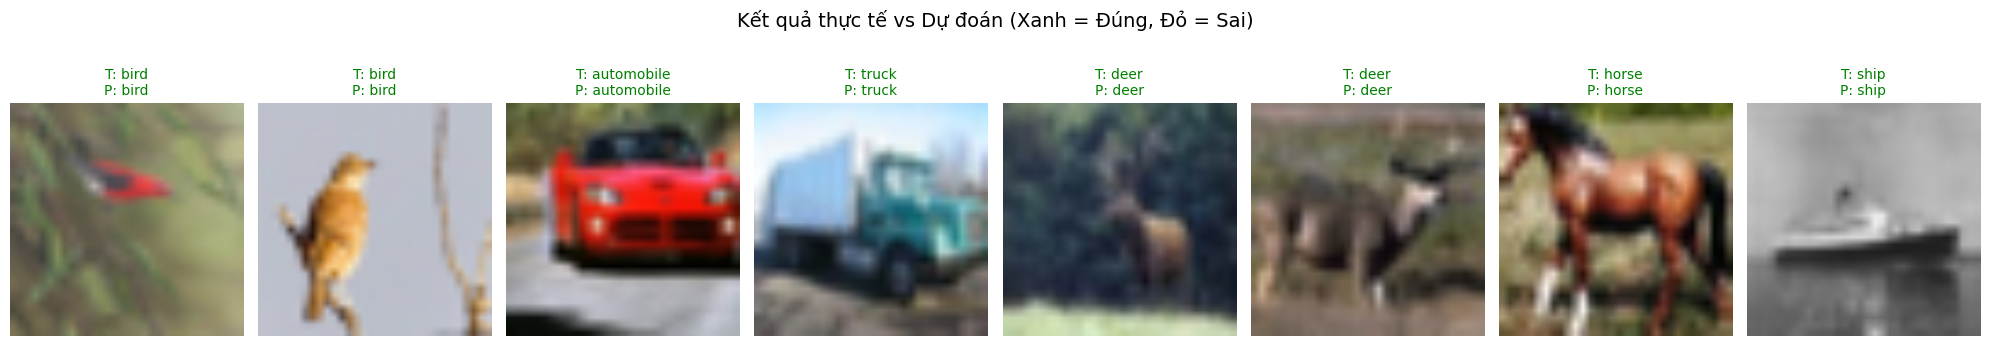

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# 1. Tạo loader để lấy ảnh test ngẫu nhiên
vis_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=8,
    shuffle=True
)

dataiter = iter(vis_loader)
images, labels = next(dataiter)

# 2. Dự đoán bằng model
resnet18.eval()
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = resnet18(images)
    _, predicted = torch.max(outputs, 1)

# Hàm unnormalize để hiển thị ảnh
def unnormalize(img):
    img = img / 2 + 0.5
    return img.cpu().numpy()

images_np = unnormalize(images)

# 4. Vẽ ảnh + nhãn (xanh đúng, đỏ sai)
plt.figure(figsize=(20, 4))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(np.transpose(images_np[i], (1, 2, 0)))
    plt.axis('off')

    true_label = trainset.classes[labels[i]]
    pred_label = trainset.classes[predicted[i]]

    # So sánh đúng / sai
    if predicted[i] == labels[i]:
        color = 'green'
    else:
        color = 'red'

    # Hiển thị text dưới ảnh
    plt.title(
        f"T: {true_label}\nP: {pred_label}",
        color=color,
        fontsize=10
    )

plt.suptitle("Kết quả thực tế vs Dự đoán (Xanh = Đúng, Đỏ = Sai)", fontsize=14)
plt.tight_layout()
plt.show()


# **Step8: Tính điểm chính sát Accuracy Score**

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn

# 1. Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Chuẩn bị dữ liệu Test 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
# Batch size này chỉ để test, không ảnh hưởng kết quả, để 32 hoặc 64 đều được
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

# 3. Khởi tạo lại kiến trúc model (Giống hệt lúc train)
model_to_test = models.resnet18(weights=None) # Không cần load weight ImageNet nữa
num_ftrs = model_to_test.fc.in_features
model_to_test.fc = nn.Linear(num_ftrs, 10)

# 4. LOAD WEIGHTS TỪ FILE BẠN ĐÃ LƯU
model_to_test.load_state_dict(torch.load('model_cuoi_cung.pth', map_location=device))
model_to_test.to(device)
model_to_test.eval() # Chuyển sang chế độ đánh giá

# 5. Chạy đánh giá trên toàn bộ 100 ảnh
correct = 0
total = 0
MAX_TEST = 100  # Chỉ test 100 ảnh cho nhanh

print(f"Đang chấm {MAX_TEST} ảnh")

with torch.no_grad():
    for i, data in enumerate(testloader):
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        
        outputs = resnet18(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    
        if total >= MAX_TEST:
            break

print(f'Kết quả nhanh: Độ chính xác khoảng {100 * correct // total} %')

Đang chấm 100 ảnh
Kết quả nhanh: Độ chính xác khoảng 81 %
